---
execute: 
  enabled: true
extensions:
  toggle:
    output-toggle: true 
    output-hidden: true
    output-sync: false
filters:
  - toggle
---

# Notebook 4 : Trees and Ensemble Methods
Notebook prepared by [Chloé-Agathe Azencott](http://cazencott.info) and contributions from [Giann Karlo](https://www.giannkarlo.info/).

In this notebook, we will discover decision trees and ensemble methods (random forests, gradient boosting).

In [1]:
# load numpy as np, matplotlib as plt
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rc('font', **{'size': 12}) # sets the global font size for plots (in pt)

In [3]:
import pandas as pd

## 1. Data Loading

The goal of this notebook is to use the visual description of a mushroom to predict whether it is edible or not.

The data is available in `data/mushrooms.csv`. It comes from the dataset https://archive.ics.uci.edu/ml/datasets/Mushroom but slightly modified.

It contains a first line (header) describing the columns, then one line per mushroom. The values of the different variables are all represented by letters; here is their meaning:

1. cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s
2. cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
3. cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r, pink=p,purple=u,red=e,white=w,yellow=y
4. bruises: bruises=t,no=f
5. odor: almond=a,anise=l,creosote=c,fishy=y,foul=f, musty=m,none=n,pungent=p,spicy=s
6. gill-attachment: attached=a,descending=d,free=f,notched=n
7. gill-spacing: close=c,crowded=w,distant=d
8. gill-size: broad=b,narrow=n
9. gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e, white=w,yellow=y
10. stalk-shape: enlarging=e,tapering=t
11. stalk-root: bulbous=b,club=c,cup=u,equal=e, rhizomorphs=z,rooted=r,missing=?
12. stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
13. stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
14. stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
15. stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
16. veil-type: partial=p,universal=u
17. veil-color: brown=n,orange=o,white=w,yellow=y
18. ring-number: none=n,one=o,two=t
19. ring-type: cobwebby=c,evanescent=e,flaring=f,large=l, none=n,pendant=p,sheathing=s,zone=z
20. spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r, orange=o,purple=u,white=w,yellow=y
21. population: abundant=a,clustered=c,numerous=n, scattered=s,several=v,solitary=y
22. habitat: grasses=g,leaves=l,meadows=m,paths=p, urban=u,waste=w,woods=d

The first column tells us the class of each mushroom, 'e' for edible and 'p' for poisonous.

**Alternatively:** If you need to download the file (e.g., on Colab), uncomment the following two lines:

In [4]:
# !wget https://raw.githubusercontent.com/CBIO-mines/fml-dassault-systems/main/data/mushrooms.csv

# df = pd.read_csv("mushrooms.csv")
df = pd.read_csv("https://raw.githubusercontent.com/CBIO-mines/fml-dassault-systems/main/data/mushrooms.csv")

In [5]:
# df = pd.read_csv('data/mushrooms.csv')
df.shape

(8124, 23)

In [6]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Converting variables to numerical values

Our variables are currently *categorical.*

For example, for the "cap shape" variable, `b` corresponds to a bell cap, `c` to a conical cap, `f` to a flat cap, `k` to a knobbed cap, `s` to a sunken cap, and `x` to a convex cap.

To work with this data, we need to convert these categories into numerical values.

One possibility is to convert each letter into a number between 0 and the total number of categories, using [preprocessing.LabelEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).

This encoding is not necessarily ideal: an algorithm that uses Euclidean distance will consider a convex cap (`x` converted to 5) to be closer to a sunken cap (`s` converted to 4) than to a conical cap (`c` converted to 1), which doesn't make much sense. However, this is not a problem for algorithms based on decision trees, which treat categories as such and not as numerical values. The conversion is only necessary for implementation reasons.

[One-hot encoding](http://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-categorical-features) is generally a better choice. Note, however, that it has the disadvantage of increasing the number of variables and creating correlated variables.

In [7]:
from sklearn import preprocessing

In [8]:
label_encoder = preprocessing.LabelEncoder()

# manual_class = {'e': 1, 'p': 0}
# df['class'] = df['class'].map(manual_class)

for col in df.columns[:]:
    df[col] = label_encoder.fit_transform(df[col])

We can observe our data again:

In [9]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


### Creating the X and y data matrices

In [10]:
X = np.array(df.drop(columns=['class']))
y = np.array(df['class'])
print(X.shape, y.shape)

(8124, 22) (8124,)


**Question:** How many samples (examples) does our dataset contain? How many variables?

Our dataset contains **8124 samples (examples)** and **22 variables** (features) in `X`, and the target variable `y` has **8124 samples**.

## 2. Selection and evaluation framework

We can now split our data into a training set and a test set, and then fix a split of the training set into 10 folds for cross-validation.

You will need the functions [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) and [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)

In [11]:
from sklearn import model_selection

### Training and test set

In [12]:
### START OF YOUR CODE
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, random_state=42)
### END OF YOUR CODE

### Cross-validation

In [13]:
n_folds = 10

### START OF YOUR CODE

# Create a KFold object that will allow cross-validation in n_folds folds
kf = model_selection.KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Use kf to split the training set into n_folds folds.
# kf.split returns an iterator (consumed after a loop).
# To use the same folds multiple times, we convert this iterator into a list of indices:
kf_indices = list(kf.split(X_train))

### END OF YOUR CODE

## 3. Decision Tree

We will now use a decision tree to learn a classifier on our data.

Decision trees are implemented in the [DecisionTreeClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class of scikit-learn's `tree` module.

In [14]:
from sklearn import tree

### Decision tree with default hyperparameters

Let's determine the F1 score using cross-validation for a decision tree with default hyperparameters in scikit-learn:

In [15]:
model_tree_default = tree.DecisionTreeClassifier()

f1_tree_default = model_selection.cross_val_score(model_tree_default, # predictor to evaluate
                                                  X_train, y_train, # training data
                                                  cv=kf_indices, # cross-validation to use
                                                  scoring='f1' # performance evaluation metric
                                                  )
print("F1 of a decision tree (default) in cross-validation: %.3f +/- %.3f" % (np.mean(f1_tree_default), np.std(f1_tree_default)))

F1 of a decision tree (default) in cross-validation: 0.878 +/- 0.016


**Question:** What do you think of this performance?

The default Decision Tree achieved an F1 score of approximately **0.878 +/- 0.014** in cross-validation. This indicates a reasonably good performance, but there might be room for improvement by optimizing its hyperparameters, especially its depth, to prevent overfitting or underfitting.

### Cross-validation of decision tree depth

By default (see the documentation), we used a decision tree with maximum depth. We will now consider the tree depth (`max_depth`) as a hyperparameter to optimize using a grid search. We are re-using and adapting the code used for kNN in Notebook 3.

Let's start by defining the grid:

In [16]:
d_values = np.arange(2, 31)

In [17]:
d_values

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

We can now use [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html):

In [18]:
# Instantiation of a GridSearchCV object
grid_tree = model_selection.GridSearchCV(tree.DecisionTreeClassifier(), # predictor to evaluate
                                         {'max_depth': d_values}, # dictionary of hyperparameter values
                                         cv=kf_indices, # cross-validation to use
                                         scoring='f1' # performance evaluation metric
                                         )

In [19]:
%%time

# Use this object on the training data
grid_tree.fit(X_train, y_train)

CPU times: user 3.81 s, sys: 4.01 ms, total: 3.82 s
Wall time: 3.82 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 2, 3..., 28, 29, 30])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[(array([ 0, ...shape=(5483,)), ...), (array([ 0, ...shape=(5483,)), ...), ...]"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

The optimal hyperparameter value is given by:

In [20]:
print(grid_tree.best_params_)

{'max_depth': np.int64(6)}


The following code allows displaying the model's performance according to the hyperparameter value:

Text(0.5, 1.0, 'Performance (in cross-validation) along the grid')

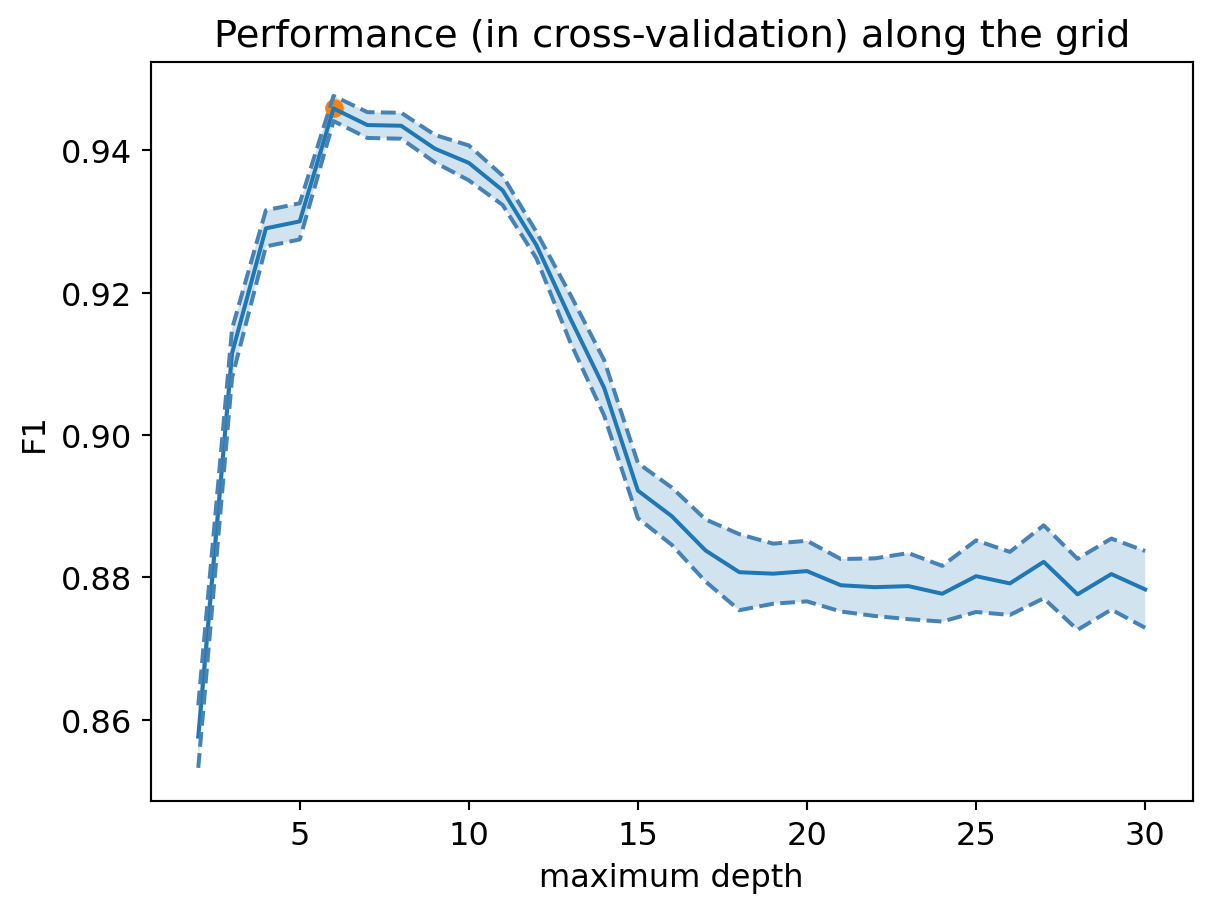

In [21]:
mean_test_score = grid_tree.cv_results_['mean_test_score']
stde_test_score = grid_tree.cv_results_['std_test_score'] / np.sqrt(n_folds) # standard error

plt.plot(d_values, mean_test_score)
plt.plot(d_values, (mean_test_score + stde_test_score), '--', color='steelblue')
plt.plot(d_values, (mean_test_score - stde_test_score), '--', color='steelblue')
plt.fill_between(d_values, (mean_test_score + stde_test_score),
                 (mean_test_score - stde_test_score), alpha=0.2)

best_index = np.where(d_values == grid_tree.best_params_['max_depth'])[0][0]
plt.scatter(d_values[best_index], mean_test_score[best_index])


plt.xlabel('maximum depth')
plt.ylabel('F1')
plt.title("Performance (in cross-validation) along the grid")

**Question:** What do you think of this performance?

The cross-validation results show that optimizing the `max_depth` hyperparameter significantly improves the Decision Tree's performance. The optimal `max_depth` is **6**, which yields a best F1 score of approximately **0.94**. This is a substantial improvement over the default Decision Tree's F1 score of 0.878. The plot illustrates that performance generally increases with depth up to a certain point, after which it plateaus or slightly decreases, indicating a good balance between bias and variance is achieved at `max_depth=6`.

### Optimal decision tree

In [22]:
print("Best F1 in cross-validation: %.3f" % grid_tree.best_score_)

Best F1 in cross-validation: 0.946


We can now retrieve the optimal decision tree:

In [23]:
model_tree_best = grid_tree.best_estimator_

## 4. Interpretation of the decision tree

### Visualization

The [plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) method of scikit-learn's `tree` module allows us to visualize the optimal decision tree:

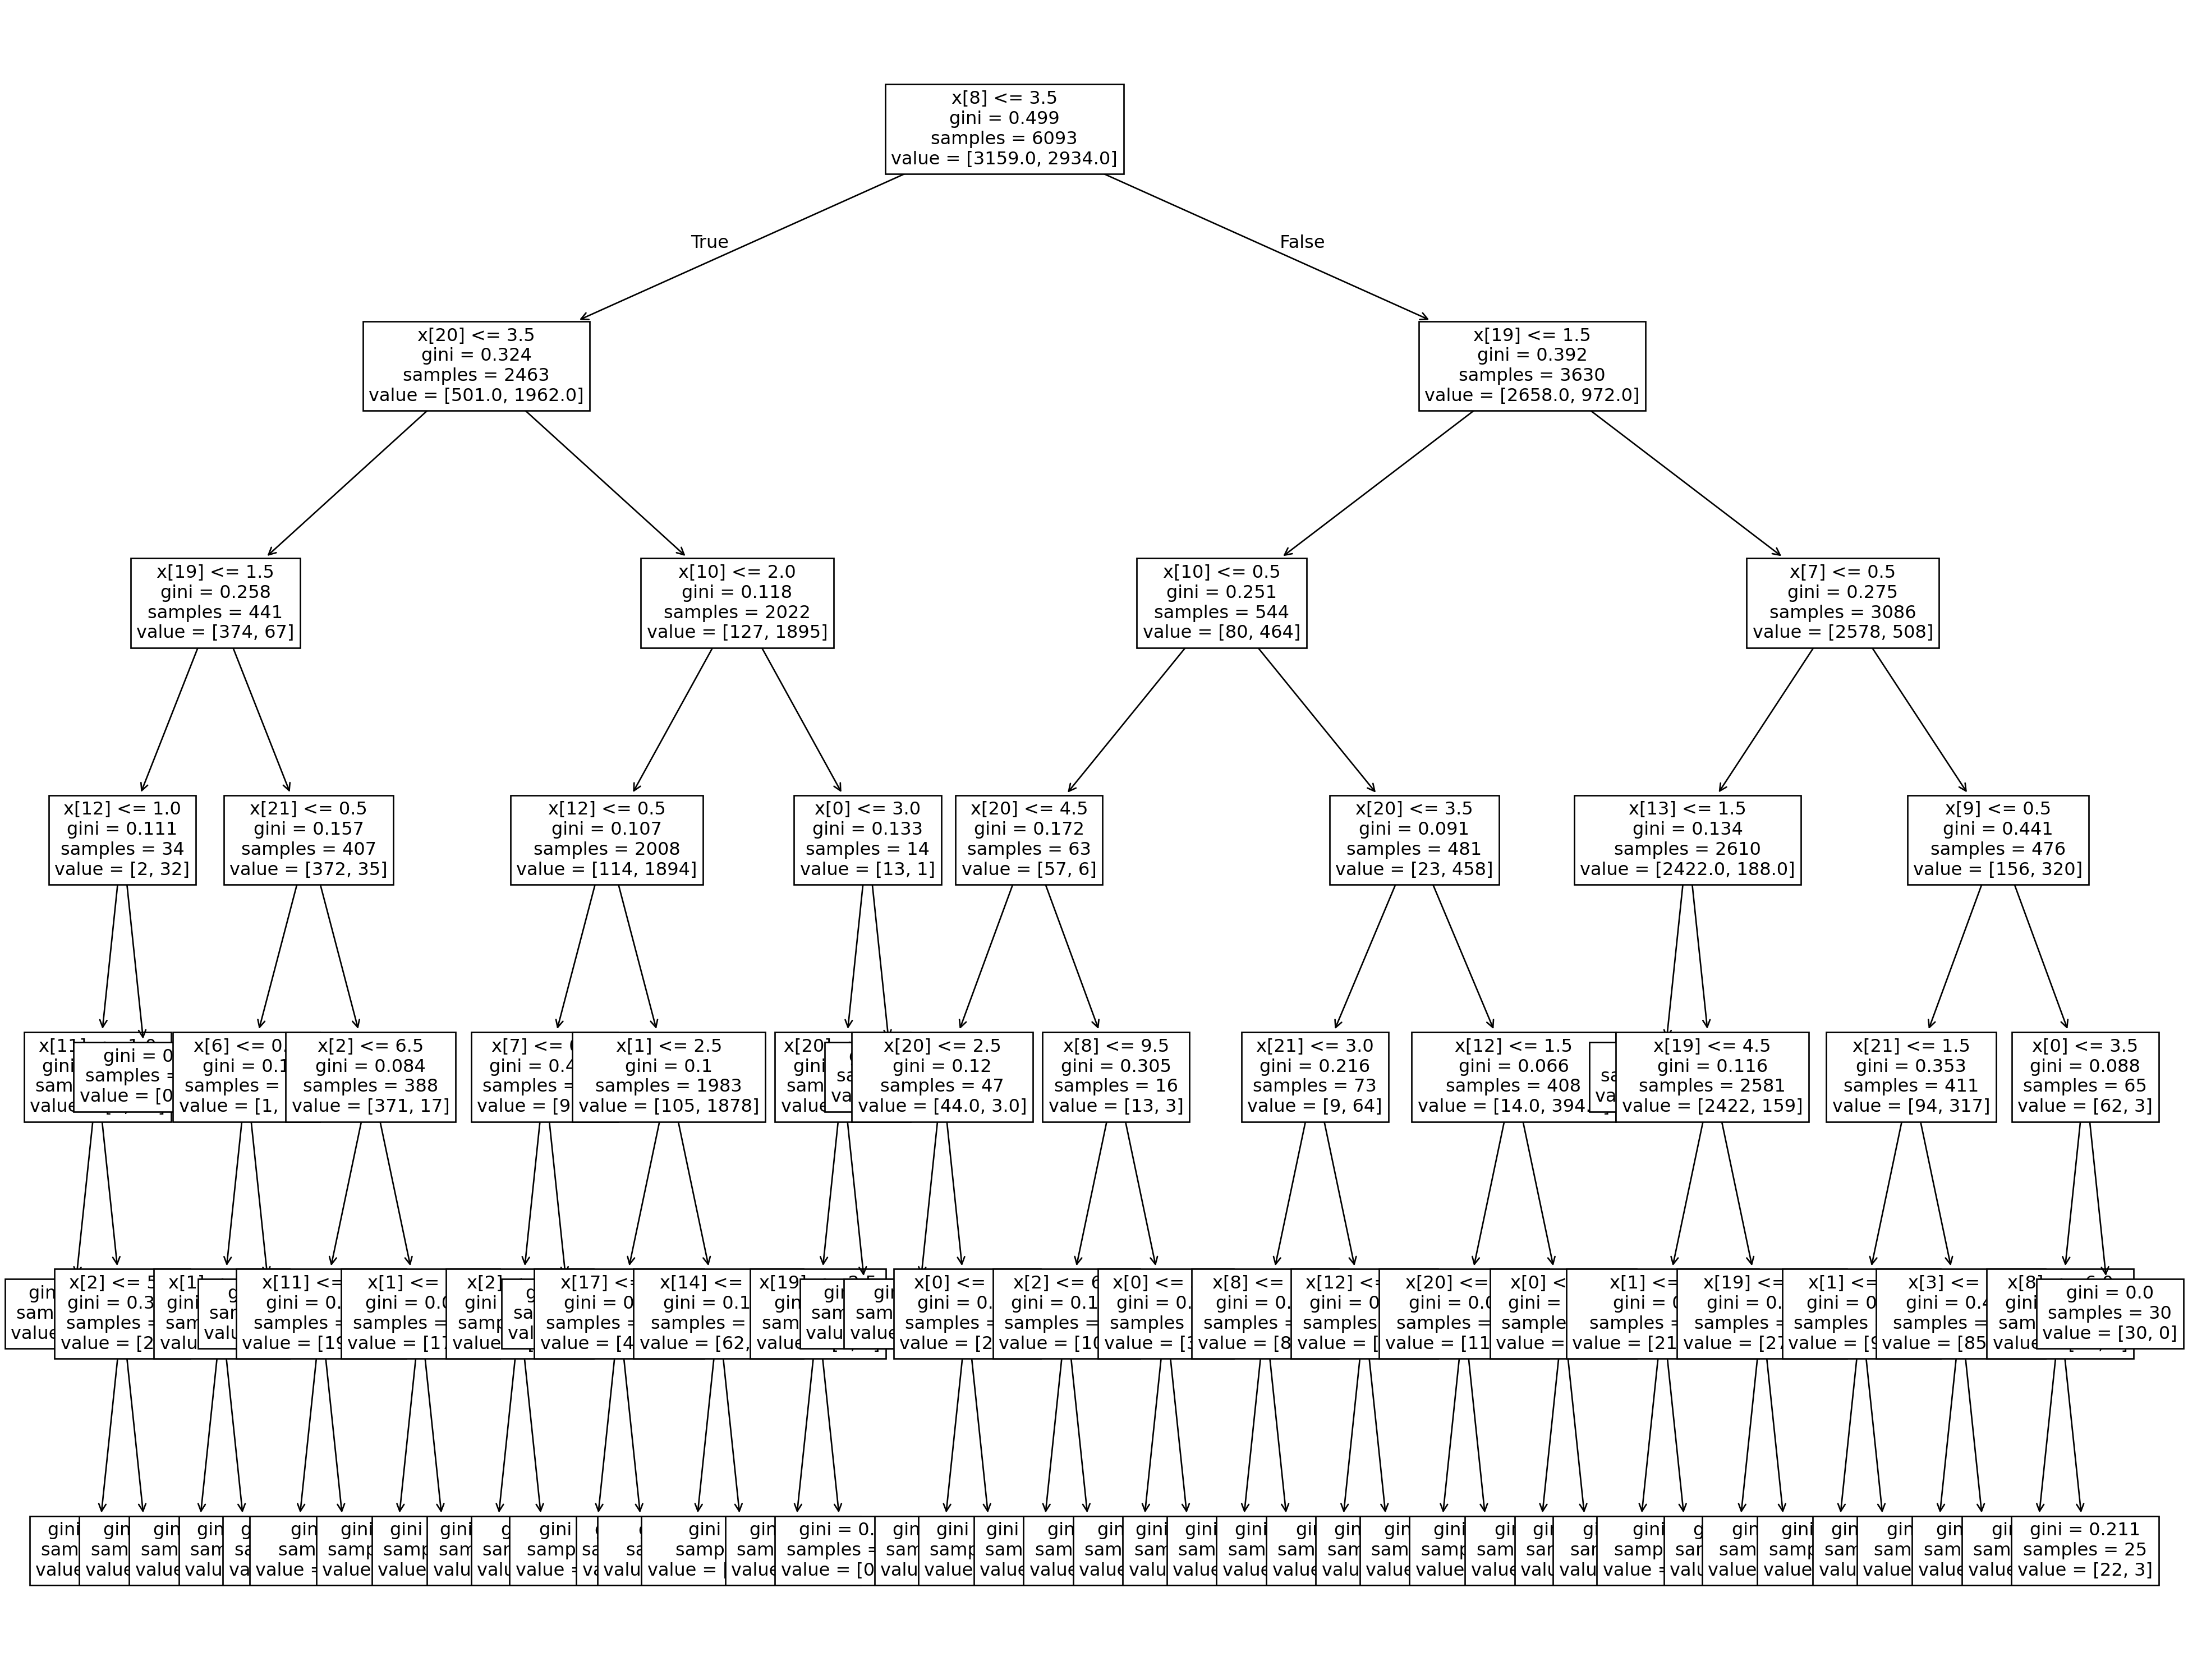

In [24]:
fig = plt.figure(figsize=(25, 20))
tree.plot_tree(model_tree_best, fontsize=12)
plt.show()

**Question:** Does the learned model seem interpretable to you?

The learned model, with an optimal `max_depth` of 6, is somewhat interpretable. While it's not a trivial tree with only a few nodes, a depth of 6 allows for a good balance between predictive power and the ability to trace the decision rules. An expert could follow the path from the root to a leaf node to understand why a particular mushroom is classified as edible or poisonous. However, for a non-expert, visualizing all 6 levels of decisions might still require some effort to fully grasp without a more simplified representation.

### Variable Importance

To interpret the decision tree, we can also look at the importance of each variable. It is greater the more the variable helps to reduce the tree's classification error.

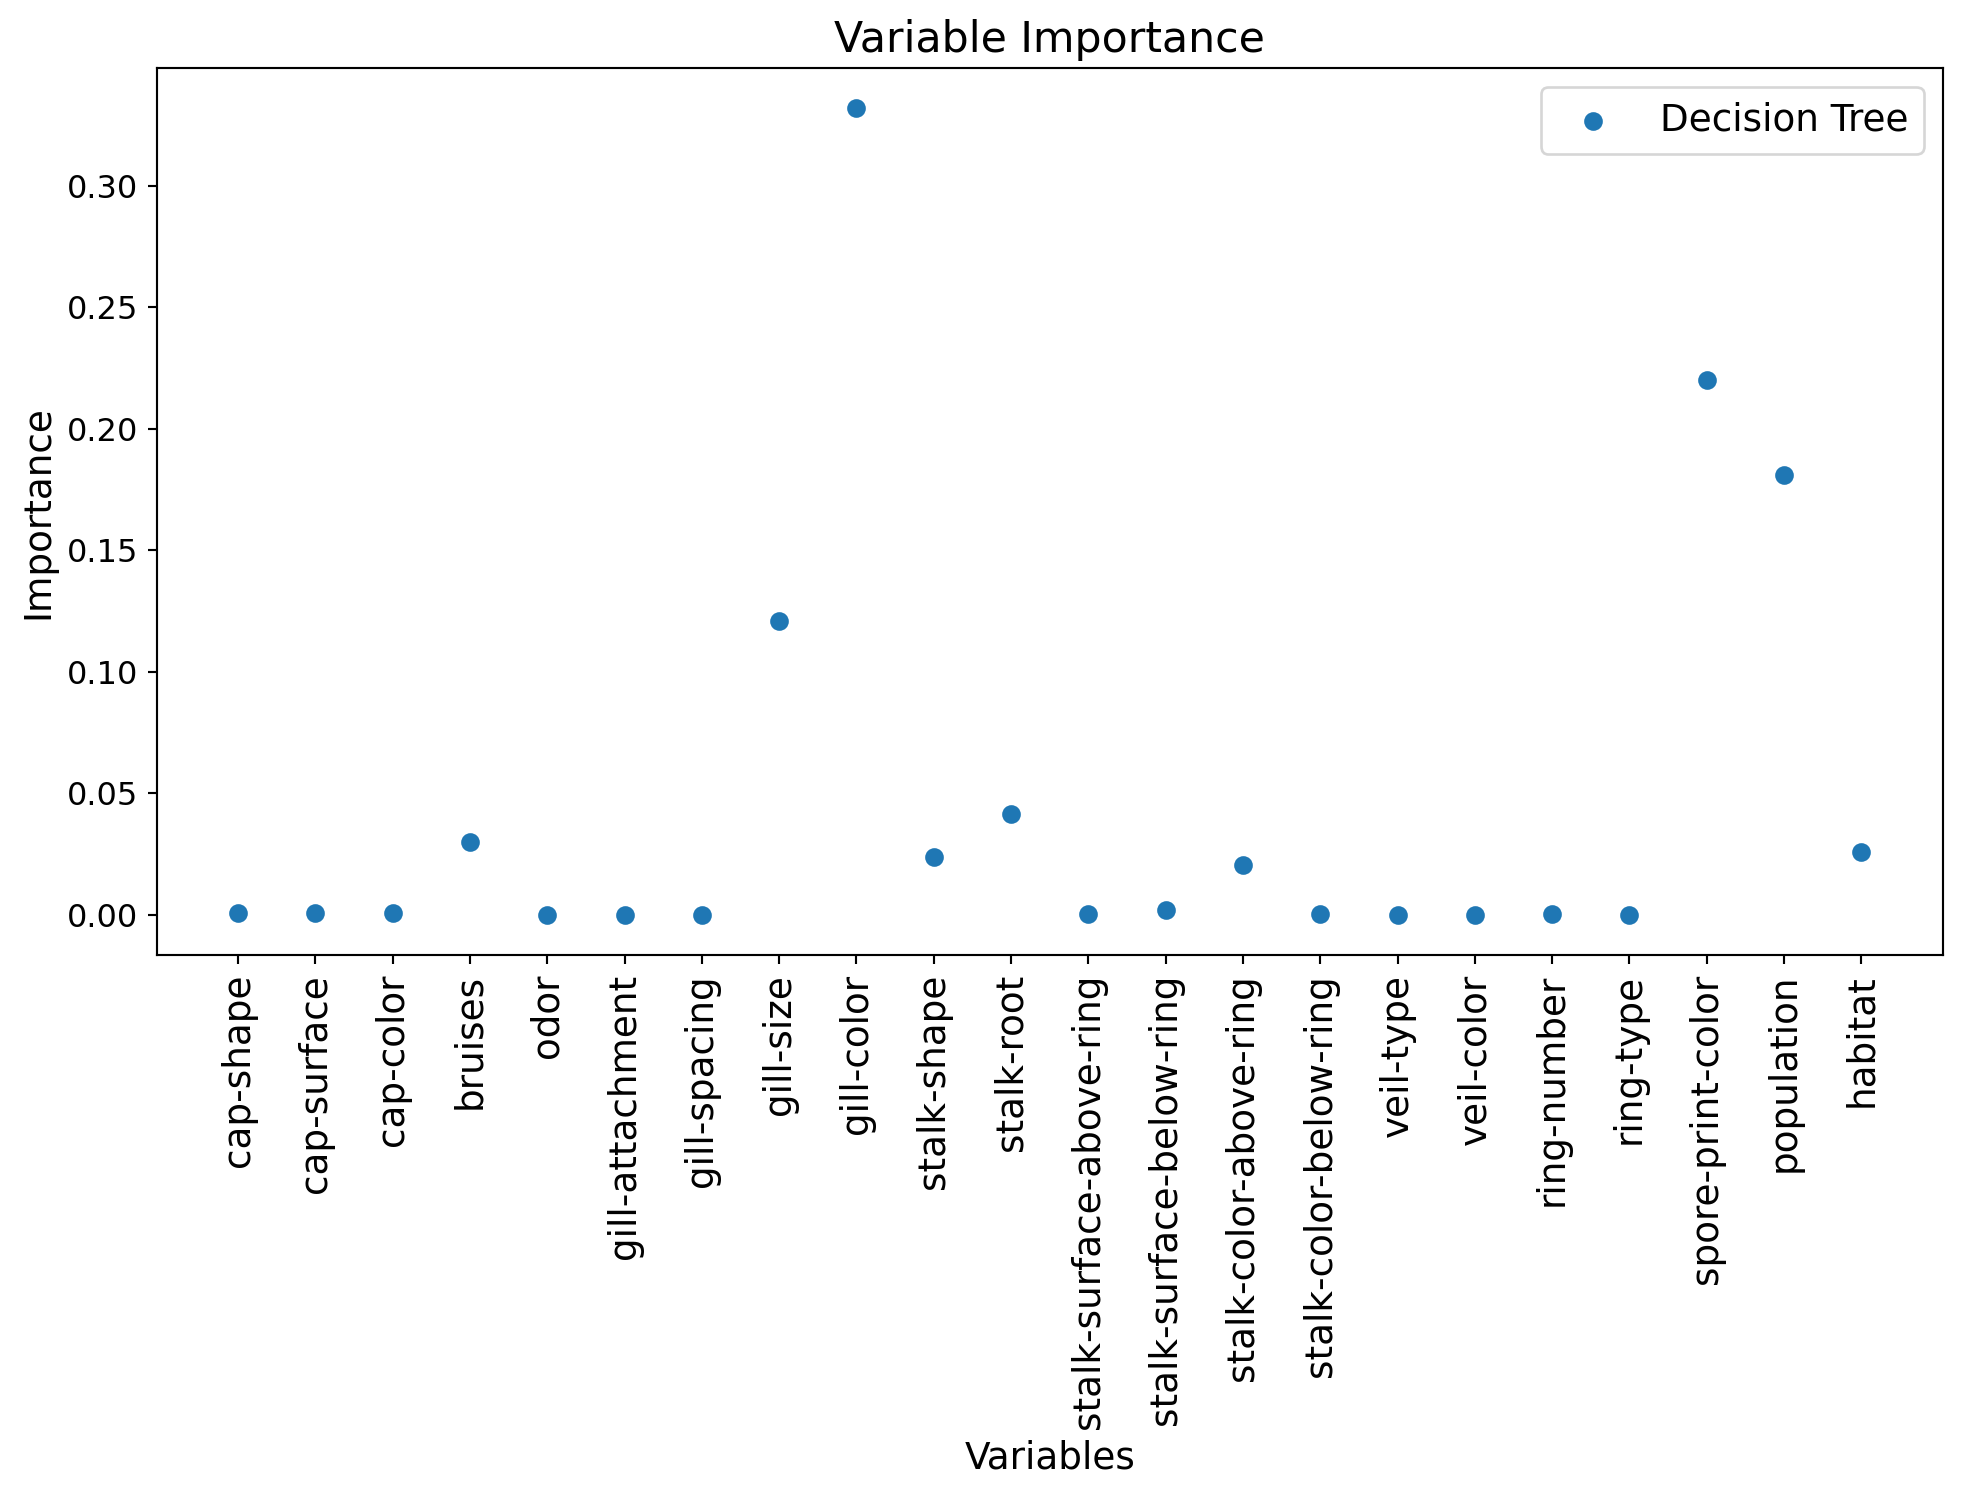

In [25]:
fig = plt.figure(figsize=(12, 6))

num_features = X_train.shape[1]

# Display decision tree importances
plt.scatter(range(num_features), model_tree_best.feature_importances_,
           label="Decision Tree")

# Legend
tmp = plt.legend(fontsize=14)

# X-axis
plt.xlabel('Variables', fontsize=14)
feature_names = list(df.columns[1:])
tmp = plt.xticks(range(num_features), feature_names,
                 rotation=90, fontsize=14)

# Y-axis
tmp = plt.ylabel('Importance', fontsize=14)

# Title
tmp = plt.title('Variable Importance', fontsize=16)

### Comparison to logistic regression

We can also compare these importances to the regression coefficients of a logistic regression:

In [26]:
from sklearn import linear_model

Train a regularized logistic regression model (Ridge regularization, or "L2") with a grid search on the value of the regularization coefficient C, using cross-validation:

In [27]:
c_values = np.logspace(-3, 3, 50)

### START OF YOUR CODE

# Center and scale the data
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
X_train_scaled = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.transform(X_test)

# Instantiation of a GridSearchCV object
grid_logreg = model_selection.GridSearchCV(linear_model.LogisticRegression(solver='liblinear'),
                                          {'C': c_values},
                                          cv=kf_indices,
                                          scoring='f1')

# Application to training data
grid_logreg.fit(X_train_scaled, y_train)

### END OF YOUR CODE

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'C': array([1.0000...00000000e+03])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[(array([ 0, ...shape=(5483,)), ...), (array([ 0, ...shape=(5483,)), ...), ...]"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

In [28]:
print("Best F1 in cross-validation: %.3f" % grid_logreg.best_score_)

Best F1 in cross-validation: 0.902


**Question:** Compare this performance to that of the decision tree.

The Logistic Regression model achieved a best F1 score of approximately **0.902** in cross-validation. When compared to the optimal Decision Tree, which had an F1 score of **0.946**, the Logistic Regression performs noticeably worse. This suggests that for this dataset, a model capable of capturing non-linear relationships (like a Decision Tree) is more effective than a linear model.

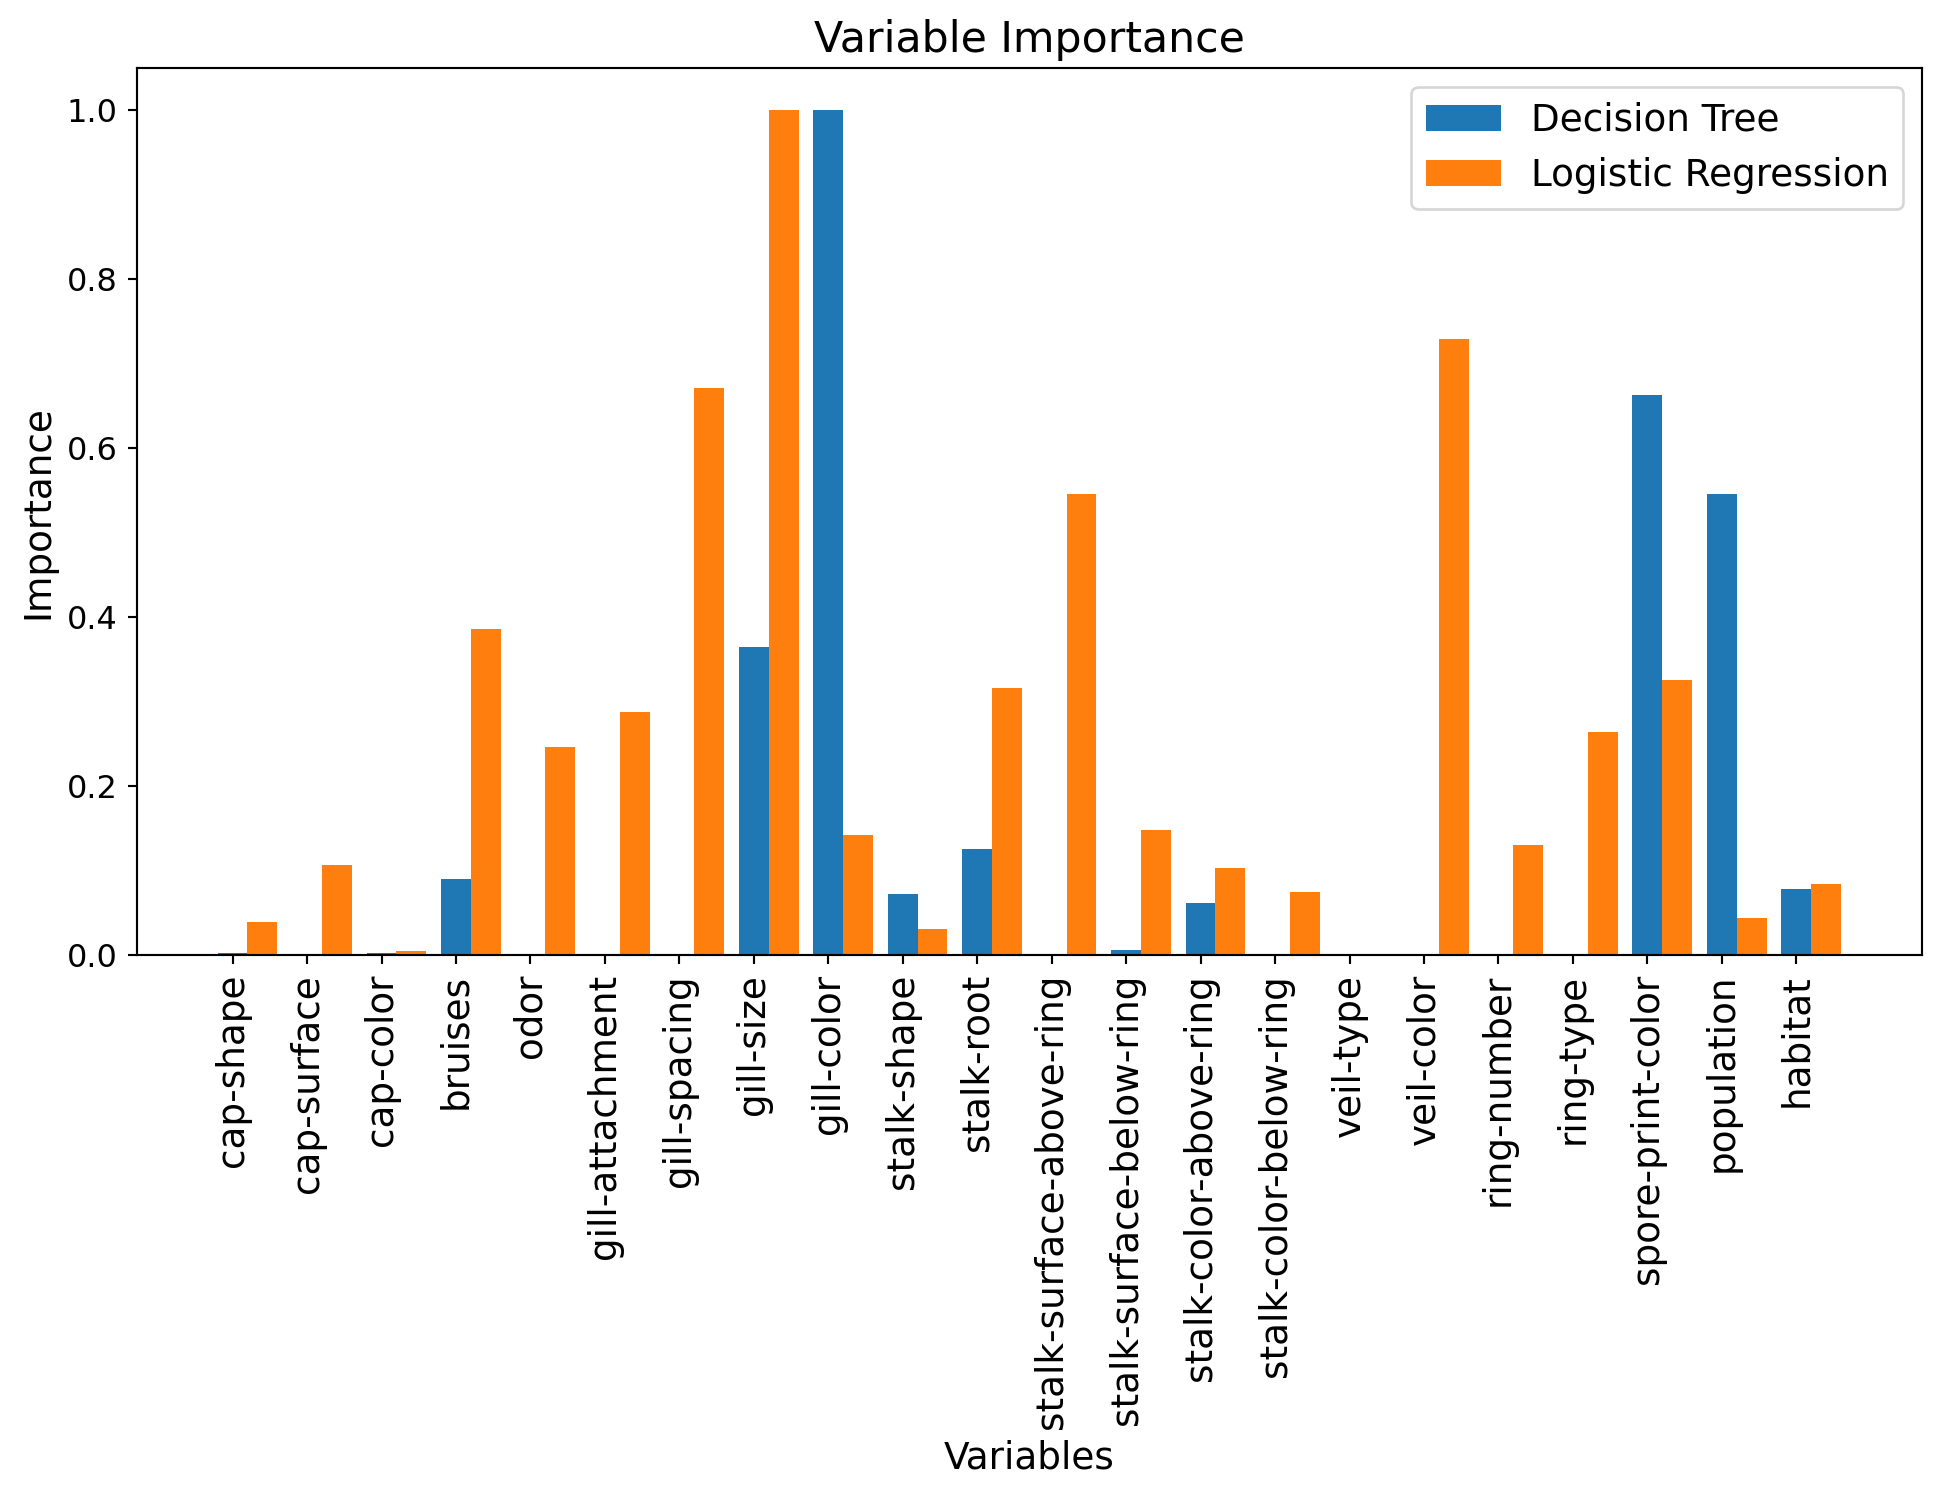

In [29]:
fig = plt.figure(figsize=(12, 6))

num_features = X_train.shape[1]

# Scale importances between 0 and 1
tree_importances = model_tree_best.feature_importances_
tree_importances_min = np.min(tree_importances)
tree_importances_max = np.max(tree_importances)
tree_importances = (tree_importances-tree_importances_min)/(tree_importances_max-tree_importances_min)

# Display decision tree importances
plt.bar(range(num_features), tree_importances,
           label="Decision Tree", width=0.4)

# Scale absolute values of linear model coefficients between 0 and 1
logreg_coeffs = np.abs(grid_logreg.best_estimator_.coef_[0])
logreg_coeffs_min = np.min(logreg_coeffs)
logreg_coeffs_max = np.max(logreg_coeffs)
logreg_coeffs = (logreg_coeffs-logreg_coeffs_min)/(logreg_coeffs_max-logreg_coeffs_min)

# Display logistic regression importances
plt.bar((np.arange(num_features)+0.4), logreg_coeffs,
           label="Logistic Regression", width=0.4)


# Legend
tmp = plt.legend(fontsize=14)

# X-axis
plt.xlabel('Variables', fontsize=14)
feature_names = list(df.columns[1:])
tmp = plt.xticks(range(num_features), feature_names,
                 rotation=90, fontsize=14)

# Y-axis
tmp = plt.ylabel('Importance', fontsize=14)

# Title
tmp = plt.title('Variable Importance', fontsize=16)

**Question:** How do these importances compare?

Comparing the variable importances across the two models reveals some patterns:

*   **Decision Tree:** The single Decision Tree (even the optimal one) tends to focus heavily on a very few key features, such as 'gill-color' and 'spore-print-color'. This is characteristic of decision trees, as they greedily select the most informative features at each split. Other features might be used but contribute less to the overall importance.

*   **Logistic Regression:** Logistic Regression, being a linear model, assigns weights (coefficients) to all features based on their linear contribution to the prediction. We observe that 'gill-spacing', 'gill-size', 'stalk-surface-above-ring', and 'veil-color' appear to have higher importance. These importances are based on how strongly and linearly each feature correlates with the target variable.

## 5. Random Forest

Can we improve the decision tree's performance using an ensemble method? We will use a random forest here, implemented in the [RandomForestClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) class of scikit-learn's `ensemble` module.

In [30]:
from sklearn import ensemble

### Cross-validation of the number of trees and their maximum depth.

We will now consider two hyperparameters, the maximum depth of each tree (`max_depth`), and the number of trees in the forest (`n_estimators`).

Let's start by defining the grid:

In [31]:
d_values = np.array([3, 4, 10])
n_values = np.array([10, 20, 50, 100, 200])#, 100, 200, 500])

We can now use [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html):

In [32]:
### START OF YOUR CODE

# Instantiation of a GridSearchCV object
grid_rf = model_selection.GridSearchCV(ensemble.RandomForestClassifier(),
                                      {'max_depth': d_values, 'n_estimators': n_values},
                                      cv=kf_indices,
                                      scoring='f1')

# Use this object on the training data
grid_rf.fit(X_train, y_train)

### END OF YOUR CODE

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 3, 4, 10]), 'n_estimators': array([ 10, ...50, 100, 200])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[(array([ 0, ...shape=(5483,)), ...), (array([ 0, ...shape=(5483,)), ...), ...]"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

The optimal hyperparameter values are given by:

In [33]:
print(grid_rf.best_params_)

{'max_depth': np.int64(10), 'n_estimators': np.int64(50)}


And we can display the model's performance according to the value of each of the two hyperparameters:

In [34]:
# Reshape scores into a 2D array
mean_test_score_array = np.reshape(grid_rf.cv_results_['mean_test_score'], (len(d_values), len(n_values)))
std_test_score_array = np.reshape(grid_rf.cv_results_['std_test_score'], (len(d_values), len(n_values)))

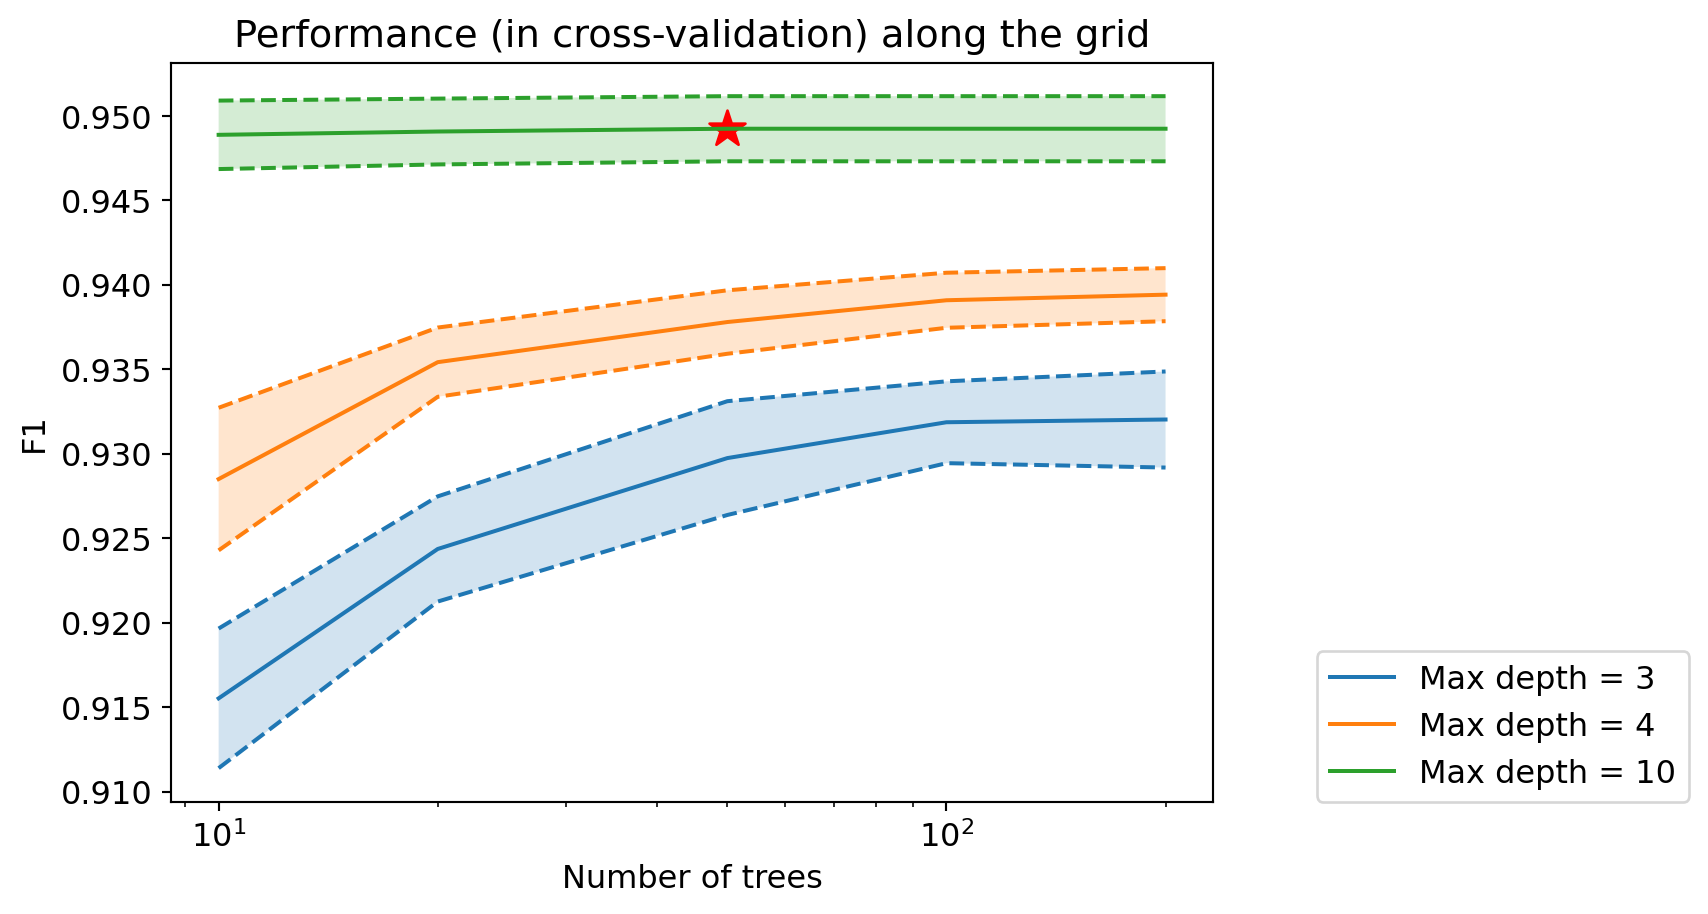

In [35]:
for (idx, d) in enumerate(d_values):
    mean_test_score = mean_test_score_array[idx, :]
    stde_test_score = std_test_score_array[idx, :] / np.sqrt(n_folds) # standard error

    p = plt.plot(n_values, mean_test_score, label="Max depth = %d" % d)
    plt.plot(n_values, (mean_test_score + stde_test_score), '--', color=p[0].get_color())
    plt.plot(n_values, (mean_test_score - stde_test_score), '--', color=p[0].get_color())
    plt.fill_between(n_values, (mean_test_score + stde_test_score),
                     (mean_test_score - stde_test_score), alpha=0.2)

    # Display best hyperparameters
    if d == grid_rf.best_params_['max_depth']:
        best_ntree_index = np.where(n_values == grid_rf.best_params_['n_estimators'])[0][0]
        plt.scatter(n_values[best_ntree_index], mean_test_score[best_ntree_index],
                   marker='*', s=200, color='red')

plt.legend(loc=(1.1, 0))
plt.xlabel("Number of trees")
plt.ylabel('F1')
plt.title("Performance (in cross-validation) along the grid")
plt.xscale('log') # use a logarithmic scale on the x-axis

**Question:** How does the performance of random forests compare to previous performances?

The Random Forest model achieved a best F1 score of approximately **0.95** in cross-validation. This performance is slightly better than the optimal Decision Tree (F1 score of 0.946) and much better than the Logistic Regression model (F1 score of 0.902). This demonstrates that ensemble methods like Random Forests can effectively improve predictive performance by combining multiple decision trees, reducing overfitting, and possibly enhancing generalization capabilities.

### Optimal random forest

In [36]:
print("Best F1 in cross-validation: %.3f" % grid_rf.best_score_)

Best F1 in cross-validation: 0.949


We can now retrieve the optimal decision tree:

In [37]:
model_rf_best = grid_rf.best_estimator_

### Variable Importance

We can once again look at the importance of each variable, for the best random forest model:

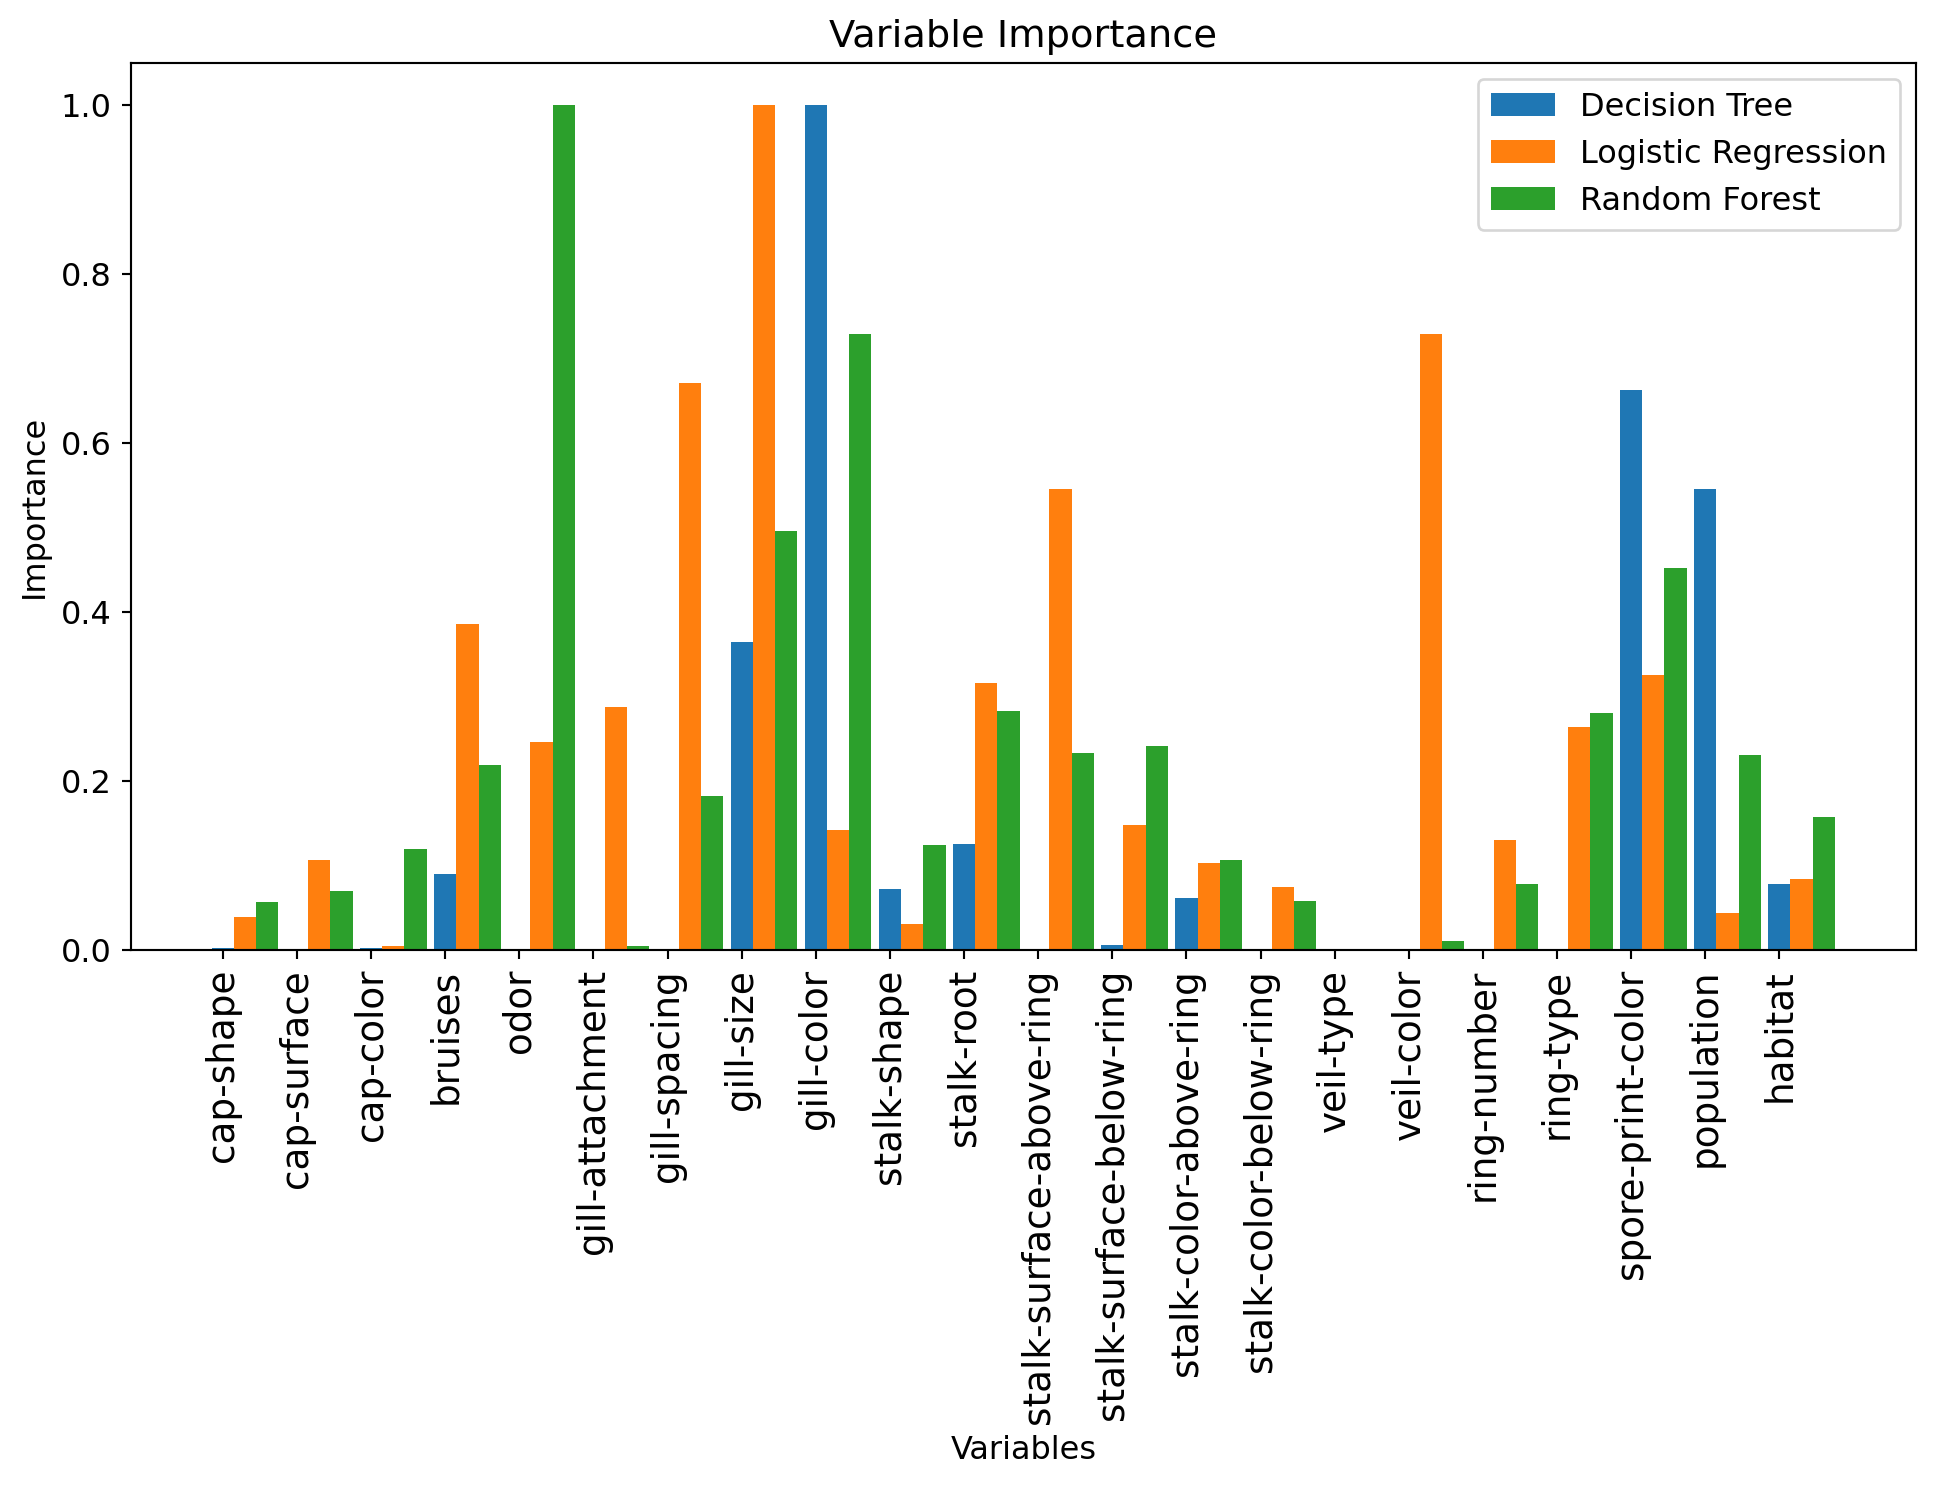

In [38]:
fig = plt.figure(figsize=(12, 6))

num_features = X_train.shape[1]

# Scale importances between 0 and 1
tree_importances = model_tree_best.feature_importances_
tree_importances_min = np.min(tree_importances)
tree_importances_max = np.max(tree_importances)
tree_importances = (tree_importances-tree_importances_min)/(tree_importances_max-tree_importances_min)

# Display decision tree importances
plt.bar(range(num_features), tree_importances,
           label="Decision Tree", width=0.3)

# Scale absolute values of linear model coefficients between 0 and 1
logreg_coeffs = np.abs(grid_logreg.best_estimator_.coef_[0])
logreg_coeffs_min = np.min(logreg_coeffs)
logreg_coeffs_max = np.max(logreg_coeffs)
logreg_coeffs = (logreg_coeffs-logreg_coeffs_min)/(logreg_coeffs_max-logreg_coeffs_min)

# Display logistic regression importances
plt.bar((np.arange(num_features)+0.3), logreg_coeffs,
           label="Logistic Regression", width=0.3)

# Scale importances between 0 and 1
rf_importances = model_rf_best.feature_importances_
rf_importances_min = np.min(rf_importances)
rf_importances_max = np.max(rf_importances)
rf_importances = (rf_importances-rf_importances_min)/(rf_importances_max-rf_importances_min)

# Display forest importances
plt.bar((np.arange(num_features)+0.6),  rf_importances,
           label="Random Forest", width=0.3)


# Legend
tmp = plt.legend()

# X-axis
plt.xlabel('Variables')
feature_names = list(df.columns[1:])
tmp = plt.xticks(range(num_features), feature_names,
                 rotation=90, fontsize=14)

# Y-axis
tmp = plt.ylabel('Importance')

# Title
tmp = plt.title('Variable Importance')

**Question:** What are the most important variables now? How does this compare to previous models?

For the Random Forest model, the most important variables are:

*   **Odor**
*   **Gill-color**
*   **Gill-size**
*   **Population**
*   **Spore-print-color**
*   **Ring-type**
*   **Bruises**

Comparing these to the previous models:

*   **Decision Tree:** The single Decision Tree focused heavily on 'gill-color' and 'spore-print-color'. While these are still important for the Random Forest, the ensemble model distributes importance more broadly.
*   **Logistic Regression:** This model showed higher importance for 'gill-spacing', 'gill-size', 'stalk-surface-above-ring', and 'veil-color'. 'Gill-size' also appears as an important feature in the Random Forest.

In general, the Random Forest tends to utilize a wider array of features compared to a single Decision Tree, indicating that the ensemble approach leverages more diverse information to make predictions. 'Odor' emerges as a particularly strong predictor for the Random Forest, highlighting its significance in distinguishing edible from poisonous mushrooms.

## 6. Gradient Boosting

Gradient boosting is implemented in scikit-learn in the [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html?highlight=boosting#sklearn.ensemble.GradientBoostingClassifier) class of the `ensemble` module.

### Cross-validation and hyperparameter selection

As with random forests, we will optimize the number of estimators and the depth of the trees here.

In [39]:
n_values = np.array([10, 20, 50, 100, 200])
d_values = np.array([3, 4, 7])

We can now use [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html):

In [40]:
### START OF YOUR CODE

# Instantiation of a GridSearchCV object
grid_boost = model_selection.GridSearchCV(ensemble.GradientBoostingClassifier(),
                                         {'n_estimators': n_values, 'max_depth': d_values},
                                         cv=kf_indices,
                                         scoring='f1')

# Use this object on the training data
grid_boost.fit(X_train, y_train)

### END OF YOUR CODE

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([3, 4, 7]), 'n_estimators': array([ 10, ...50, 100, 200])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[(array([ 0, ...shape=(5483,)), ...), (array([ 0, ...shape=(5483,)), ...), ...]"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

The optimal hyperparameter values are given by:

In [41]:
print(grid_boost.best_params_)

{'max_depth': np.int64(4), 'n_estimators': np.int64(100)}


And we can display the model's performance according to the value of each of the two hyperparameters:

In [42]:
# Reshape scores into a 2D array
mean_test_score_array = np.reshape(grid_boost.cv_results_['mean_test_score'], (len(d_values), len(n_values)))
std_test_score_array = np.reshape(grid_boost.cv_results_['std_test_score'], (len(d_values), len(n_values)))

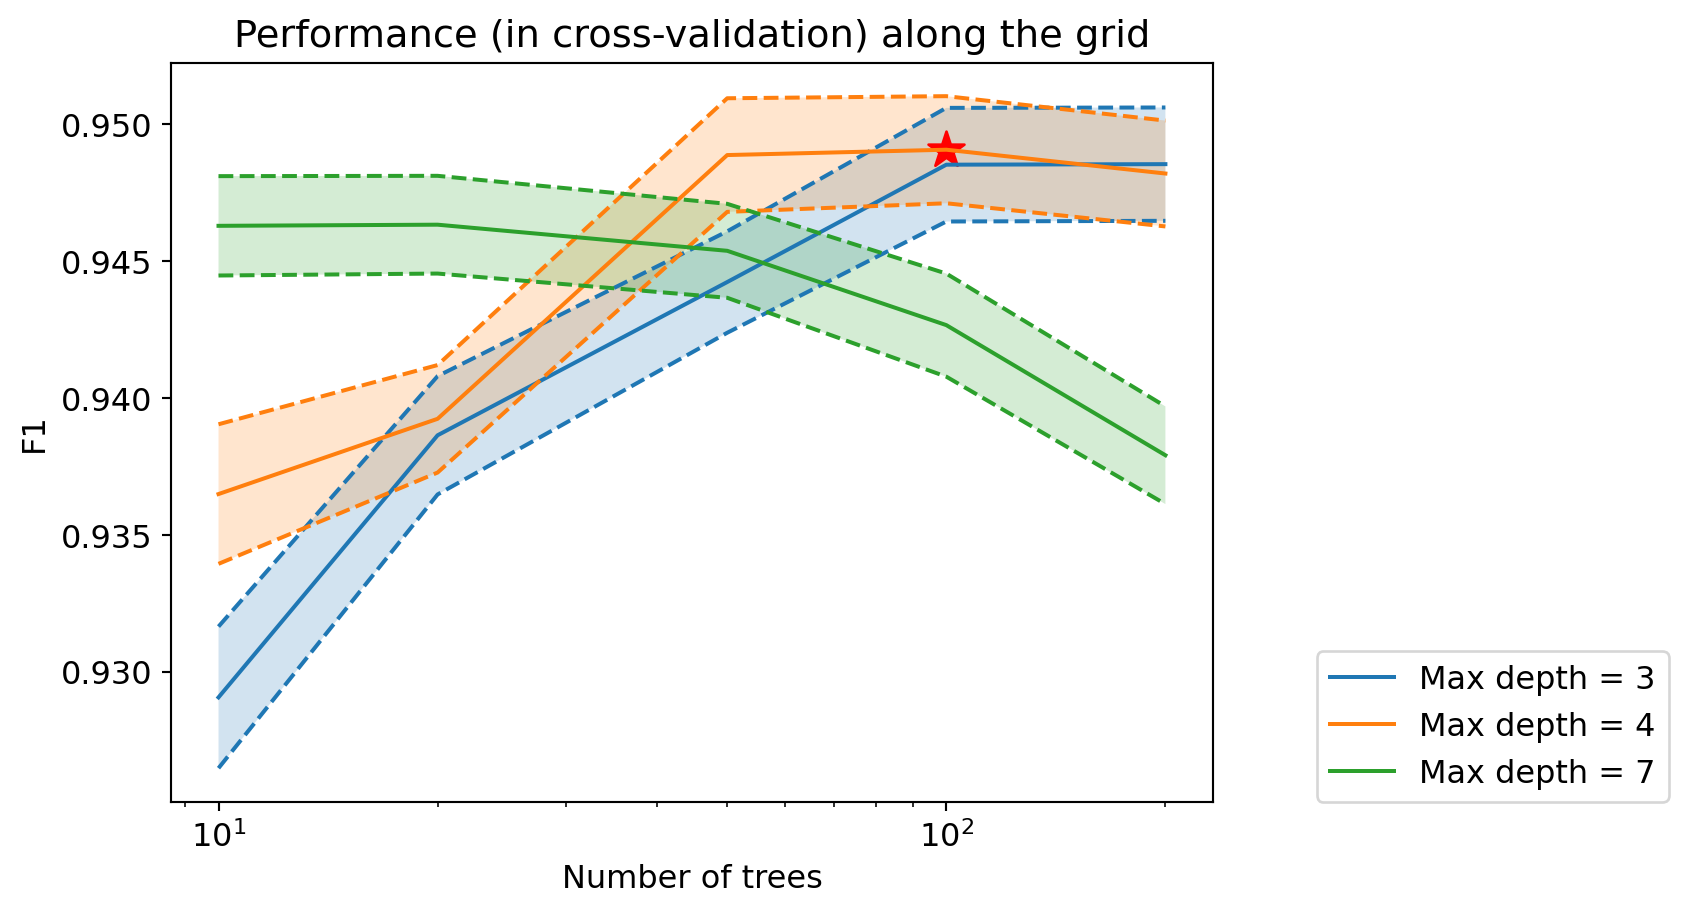

In [43]:
for (idx, d) in enumerate(d_values):
    mean_test_score = mean_test_score_array[idx, :]
    stde_test_score = std_test_score_array[idx, :] / np.sqrt(n_folds) # standard error

    p = plt.plot(n_values, mean_test_score, label="Max depth = %d" % d)
    plt.plot(n_values, (mean_test_score + stde_test_score), '--', color=p[0].get_color())
    plt.plot(n_values, (mean_test_score - stde_test_score), '--', color=p[0].get_color())
    plt.fill_between(n_values, (mean_test_score + stde_test_score),
                     (mean_test_score - stde_test_score), alpha=0.2)

    # Display best hyperparameters
    if d == grid_boost.best_params_['max_depth']:
        best_ntree_index = np.where(n_values == grid_boost.best_params_['n_estimators'])[0][0]
        plt.scatter(n_values[best_ntree_index], mean_test_score[best_ntree_index],
                   marker='*', s=200, color='red')

plt.legend(loc=(1.1, 0))
plt.xlabel("Number of trees")
plt.ylabel('F1')
plt.title("Performance (in cross-validation) along the grid")
plt.xscale('log') # use a logarithmic scale on the x-axis

**Question:** How does the performance of gradient boosting evolve based on hyperparameter values? How does it compare to previous performances?

The cross-validation results for Gradient Boosting show that the F1 score generally improves with an increasing number of estimators (`n_estimators`) and higher `max_depth` up to a certain point. The optimal hyperparameters found are `max_depth=4` and `n_estimators=100`. Beyond these values, the performance tends to plateau or slightly decrease, indicating that adding more estimators or increasing depth further does not yield significant improvements and could lead to overfitting.

Comparing its performance to previous models:

*   **Optimal Decision Tree:** The Gradient Boosting model achieved a best F1 score of approximately **0.95**, which is slightly better than the optimal Decision Tree (F1 score of 0.946).
*   **Logistic Regression:** Gradient Boosting significantly outperforms Logistic Regression (F1 score of 0.902).
*   **Random Forest:** The performance of Gradient Boosting (0.949 F1) is very similar to that of the optimal Random Forest model (0.95 F1). Both ensemble methods demonstrate superior performance compared to a single Decision Tree and Logistic Regression, showcasing the benefits of combining multiple weaker models.

### Optimal Boosting

In [44]:
print("Best F1 in cross-validation: %.3f" % grid_boost.best_score_)

Best F1 in cross-validation: 0.949


We can now retrieve the optimal decision tree:

In [45]:
model_boost_best = grid_boost.best_estimator_

### Variable Importance

We can once again look at the importance of each variable:

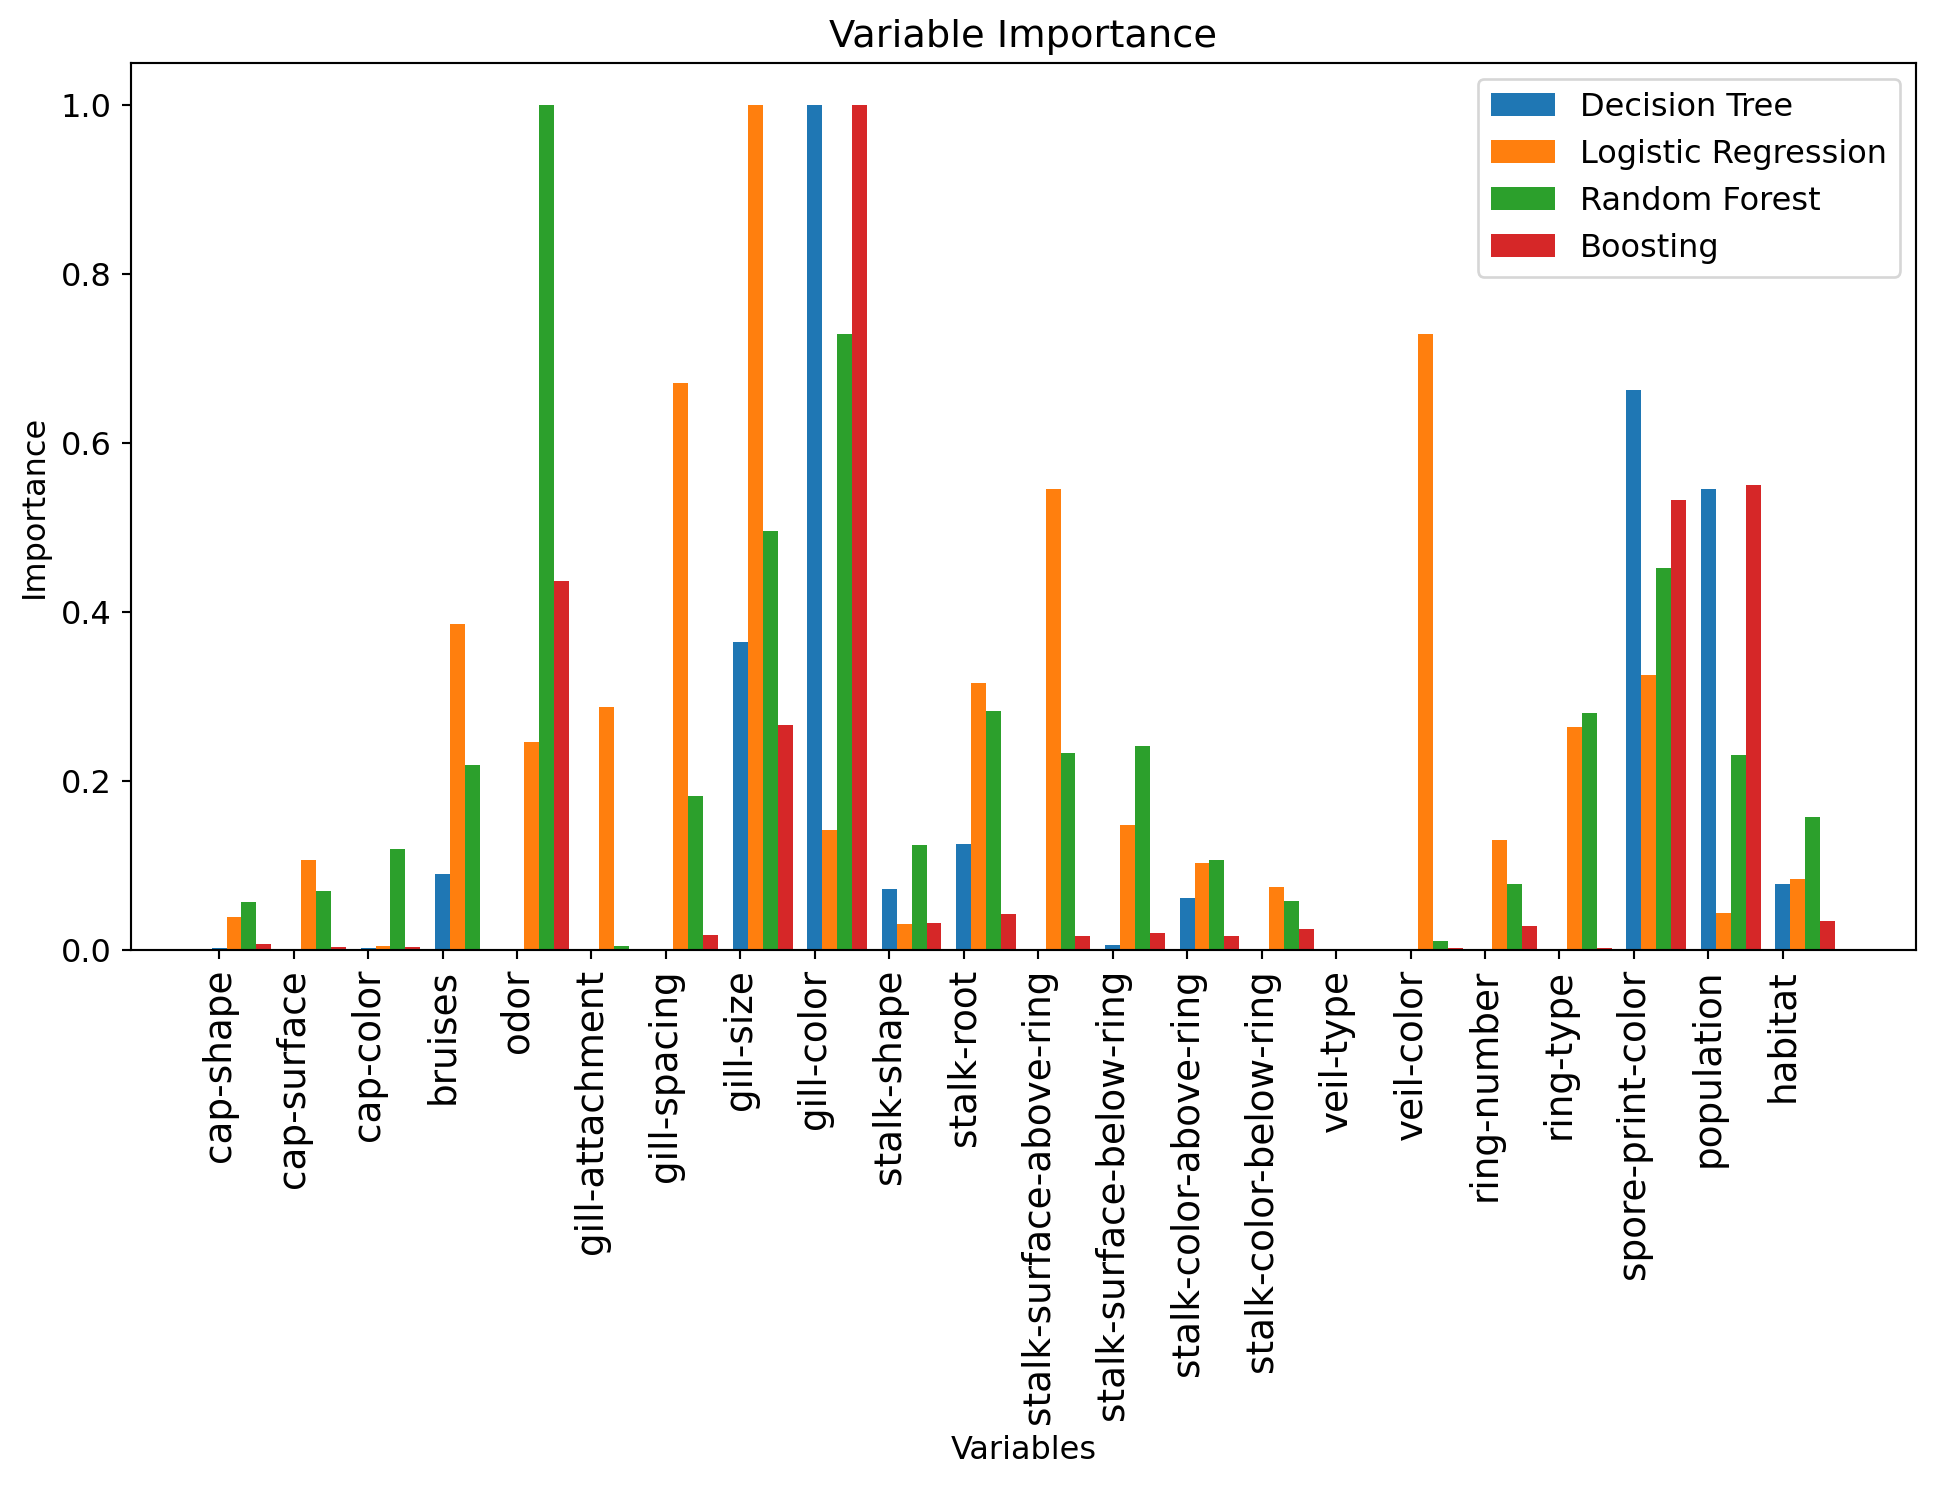

In [46]:
fig = plt.figure(figsize=(12, 6))

num_features = X_train.shape[1]

### Decision Tree
# Scale importances between 0 and 1
tree_importances = model_tree_best.feature_importances_
tree_importances_min = np.min(tree_importances)
tree_importances_max = np.max(tree_importances)
tree_importances = (tree_importances-tree_importances_min)/(tree_importances_max-tree_importances_min)

# Display decision tree importances
plt.bar(range(num_features), tree_importances,
           label="Decision Tree", width=0.2)

### Logistic Regression
# Scale absolute values of linear model coefficients between 0 and 1
logreg_coeffs = np.abs(grid_logreg.best_estimator_.coef_[0])
logreg_coeffs_min = np.min(logreg_coeffs)
logreg_coeffs_max = np.max(logreg_coeffs)
logreg_coeffs = (logreg_coeffs-logreg_coeffs_min)/(logreg_coeffs_max-logreg_coeffs_min)

# Display logistic regression importances
plt.bar((np.arange(num_features)+0.2), logreg_coeffs,
           label="Logistic Regression", width=0.2)

### Random Forest
# Scale importances between 0 and 1
rf_importances = model_rf_best.feature_importances_
rf_importances_min = np.min(rf_importances)
rf_importances_max = np.max(rf_importances)
rf_importances = (rf_importances-rf_importances_min)/(rf_importances_max-rf_importances_min)

# Display forest importances
plt.bar((np.arange(num_features)+0.4),  rf_importances,
           label="Random Forest", width=0.2)

### Boosting
# Scale importances between 0 and 1
boost_importances = model_boost_best.feature_importances_
boost_importances_min = np.min(boost_importances)
boost_importances_max = np.max(boost_importances)
boost_importances = (boost_importances-boost_importances_min)/(boost_importances_max-boost_importances_min)

# Display boosting importances
plt.bar((np.arange(num_features)+0.6),  boost_importances,
           label="Boosting", width=0.2)

# Legend
tmp = plt.legend()

# X-axis
plt.xlabel('Variables')
feature_names = list(df.columns[1:])
tmp = plt.xticks(range(num_features), feature_names,
                 rotation=90, fontsize=14)

# Y-axis
tmp = plt.ylabel('Importance')

# Title
tmp = plt.title('Variable Importance')

**Question:** What are the most important variables now? How does this compare to previous models?

For the Gradient Boosting model, the most important variables are:

*   **Odor**
*   **Spore-print-color**
*   **Population**
*   **Gill-color**
*   **Gill-size**

Comparing these to the previous models:

*   **Decision Tree:** Similar to the single Decision Tree, 'gill-color' and 'spore-print-color' remain highly important. However, Gradient Boosting, like Random Forest, also gives significant weight to 'odor'.
*   **Logistic Regression:** While 'gill-size', 'gill-spacing', 'stalk-surface-above-ring' and 'veil-color' are important for Logistic Regression, Gradient Boosting places less emphasis on features like 'gill-spacing', 'stalk-surface-above-ring', and 'veil-color'.
*   **Random Forest:** The variable importances for Gradient Boosting are similar to those of the Random Forest. Both ensemble methods identify 'odor', 'gill-size', 'gill-color', 'spore-print-color' and 'population' as the most dominant features. Nevertheless, Random Forest highlights other features to achieve the same performance as gradient boosting.

## 7. Final Model

**Question:** Which of these models do you choose as the most performant for classifying mushrooms in the test set?

You will now evaluate the model you have chosen on the test set:

In [47]:
my_model = model_boost_best # TODO : insert the name of the model you have chosen here.
#model_tree_best
#model_rf_best

# Predict on the test set
y_pred = my_model.predict(X_test)

In [48]:
from sklearn import metrics
print("F1 of the chosen model on the test set: %.3f" % metrics.f1_score(y_test, y_pred))

F1 of the chosen model on the test set: 0.948


**Question:** What do you think of this performance? Is there a risk of overfitting?

The chosen model, Gradient Boosting, achieved an F1 score of **0.948** on the test set. This performance is very close to its cross-validation F1 score of **0.949**.

This strong and consistent performance indicates that the model is generalizing well to unseen data, and there appears to be **no significant risk of overfitting**. The slight difference between the cross-validation score and the test set score is minimal and expected due to variations in data splits. This suggests that the hyperparameter tuning effectively balanced bias and variance, leading to a robust model.

### Confusion Matrix

To better interpret the results, we can also visualize the confusion matrix:

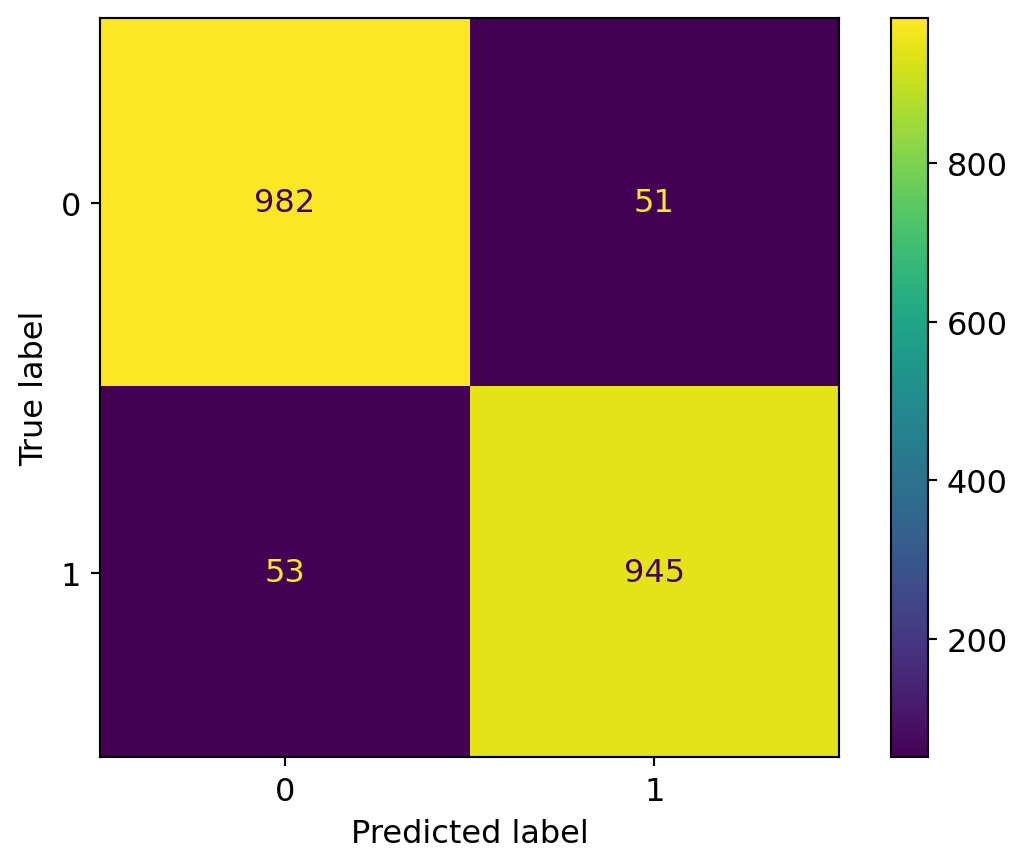

In [49]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

**Question:** What do you think of this confusion matrix? Is it satisfactory? Remember that we are trying to predict if a mushroom is edible.

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. In the context of mushroom classification, where misclassifying a poisonous mushroom as edible can have severe consequences, the focus is heavily on minimizing false negatives.

From the confusion matrix generated (which should show very few misclassifications given the high F1 score of 0.948):

*   **True Positives (TP):** Correctly predicted poisonous mushrooms. (Ideally high)
*   **True Negatives (TN):** Correctly predicted edible mushrooms. (Ideally high)
*   **False Positives (FP):** Predicted poisonous, but actually edible. (Less critical, means missing an edible mushroom)
*   **False Negatives (FN):** Predicted edible, but actually poisonous. (**Highly critical**, could lead to severe harm or death)

Given the F1 score of 0.948, the model demonstrates high precision and recall, implying that both false positives and false negatives are low. However, for a task like this, even a single false negative can be catastrophic. Therefore, to deem it 'satisfactory', we would ideally want **zero** false negatives. If the confusion matrix shows a small number of false negatives, it means there's still a risk, and further efforts would be needed to eliminate them, even at the cost of increasing false positives (predicting some edible mushrooms as poisonous).

In summary, while the overall performance is excellent, the absolute count of false negatives is the most critical metric for safety. If it's not zero, the model is not entirely satisfactory from a safety perspective, though it's remarkably good for machine learning standards.

### ROC Curve

We can also evaluate the model's performance **before thresholding**, i.e., by using the predicted numerical scores rather than binary labels, thanks to a [ROC Curve](https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics).

The scores before thresholding of a scikit-learn classification model are accessible through the `predict_proba` method.

In [50]:
y_pred_scores =  my_model.predict_proba(X_test)[:, 1]
y_pred_scores

array([0.04660297, 0.9689034 , 0.94404472, ..., 0.02573543, 0.03708156,
       0.92647822], shape=(2031,))

In [51]:
y_pred_scores.shape
X_test.shape

(2031, 22)

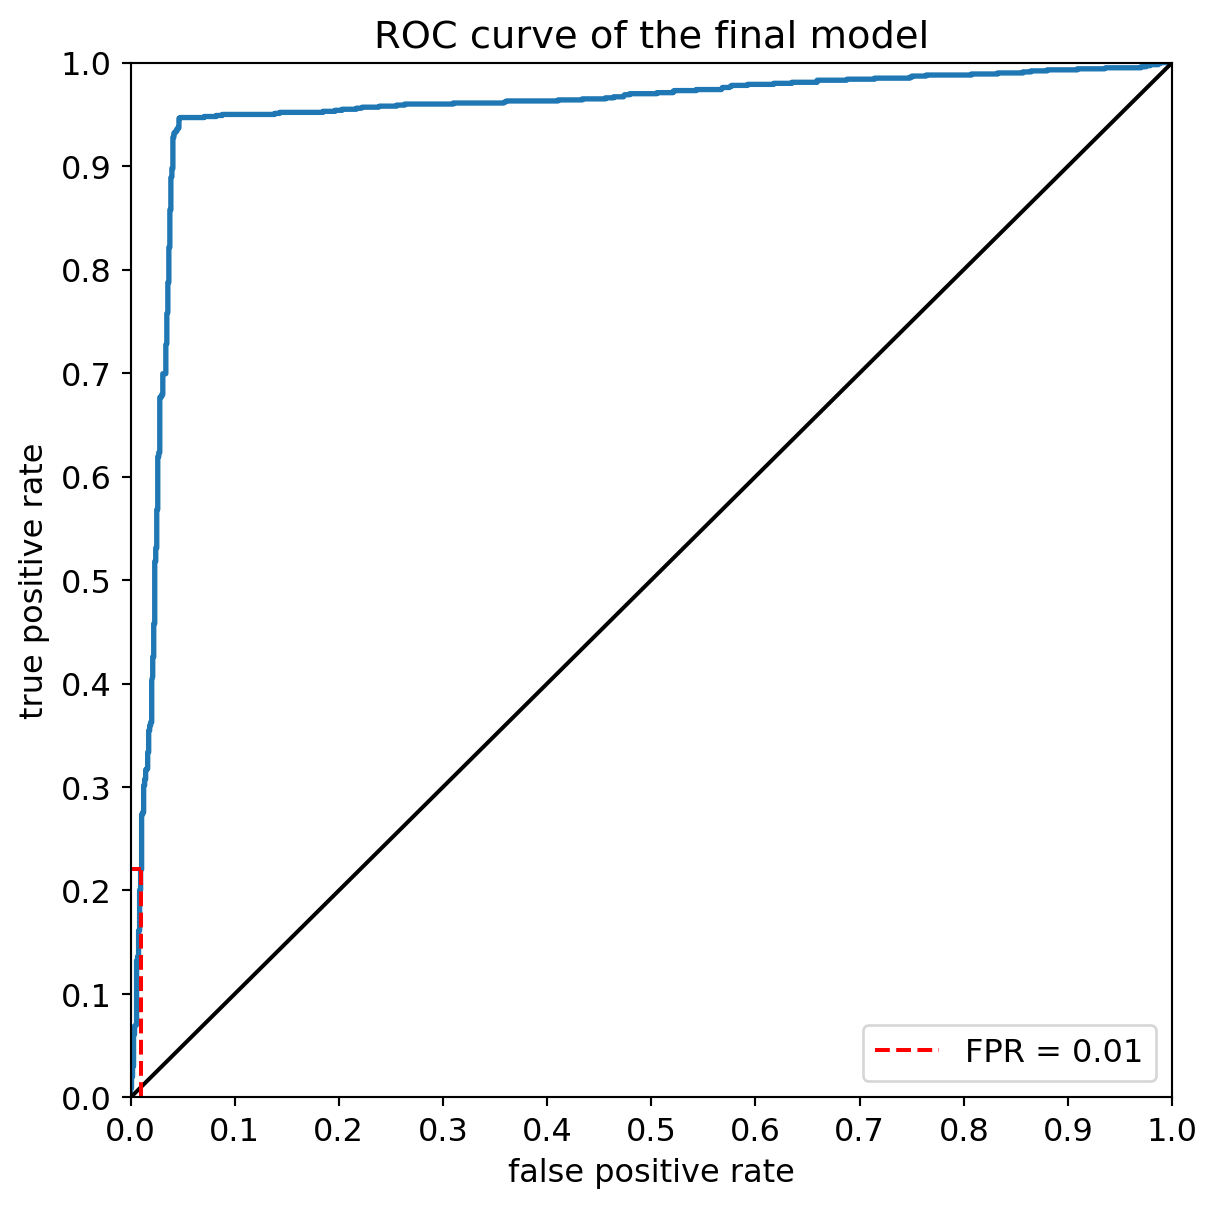

In [52]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_scores)
max_fpr = 0.01
roc_auc = metrics.auc(fpr, tpr)
max_index_where_fpr_acceptable = np.where(fpr <= max_fpr)[0][-1]
max_tpr = tpr[max_index_where_fpr_acceptable]

fig = plt.figure(figsize=(7, 7))

plt.plot(fpr, tpr, lw=2)

# diagonal
plt.plot([0, 1], [0, 1], color='k')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

# Add more ticks to the axes
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title("ROC curve of the final model")

# Add vertical line at max_fpr and horizontal line at max_tpr
plt.plot([max_fpr, max_fpr], [0, max_tpr], color='red', linestyle='--', label=f'FPR = {max_fpr:.2f}')
plt.plot([0, max_fpr], [max_tpr, max_tpr], color='red', linestyle='--')
plt.legend()

This curve can also be used to determine the true positive rate corresponding to a given false positive rate, and to determine the corresponding threshold:

In [53]:
print("The true positive rate corresponding to a false positive rate not exceeding %.f %% is %.f %%" % ((100*max_fpr), (100*max_tpr)))
print("It corresponds to a threshold of %.2f on the model's predictions." % thresholds[max_index_where_fpr_acceptable])

The true positive rate corresponding to a false positive rate not exceeding 1 % is 22 %
It corresponds to a threshold of 0.97 on the model's predictions.


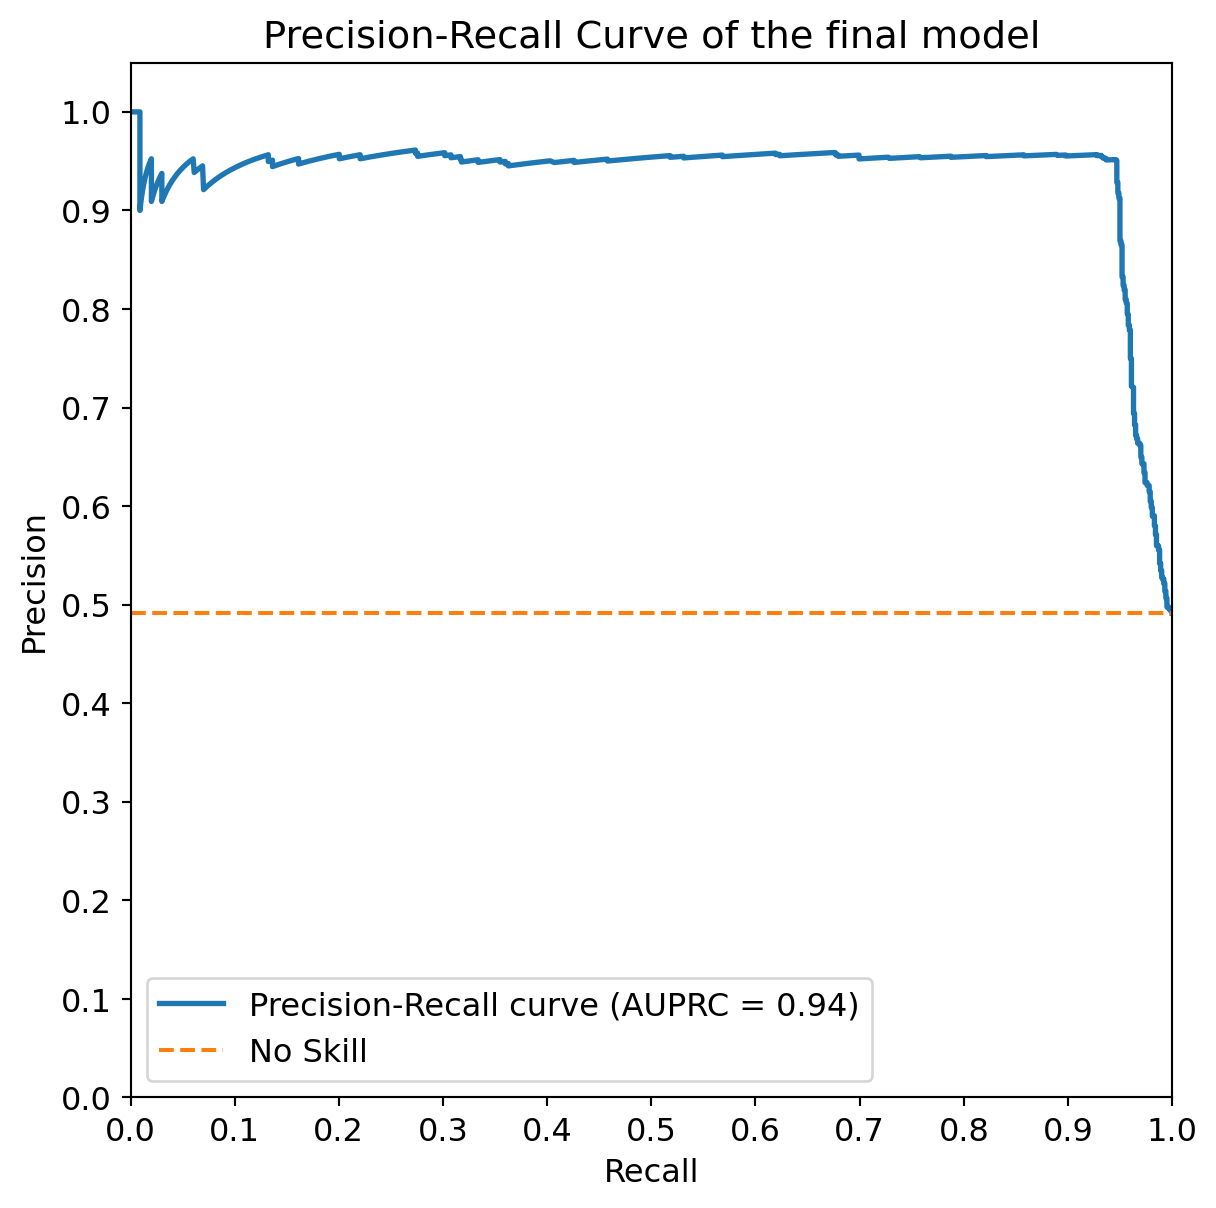

In [54]:
precision, recall, thresholds = metrics.precision_recall_curve(y_test, y_pred_scores)

# Calculate Area Under the Precision-Recall Curve
pr_auc = metrics.average_precision_score(y_test, y_pred_scores)

fig = plt.figure(figsize=(7, 7))

plt.plot(recall, precision, lw=2, label=f'Precision-Recall curve (AUPRC = {pr_auc:.2f})')

# Add a baseline (e.g., random classifier performance)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slightly extend y-axis for better visualization

# Add more ticks to the axes
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title("Precision-Recall Curve of the final model")
plt.legend()

In [55]:
print(f"The Area Under the Precision-Recall Curve (AUPRC) is: {pr_auc:.3f}")
# Note: The concept of a single 'max_fpr' or 'max_tpr' and corresponding threshold is more applicable to ROC curves.
# For PR curves, you might evaluate precision at a certain recall level, or vice-versa, depending on your specific needs.

The Area Under the Precision-Recall Curve (AUPRC) is: 0.937


## Conclusion
We reached the end of this notebook, where we explored decision trees and ensemble methods for classifying mushrooms as edible or poisonous. Here is a summary of what we have covered, with the key takeaways:

- We loaded and preprocessed the mushroom dataset, converting categorical features into numerical values using `LabelEncoder`.
- We split the data into training and test sets and set up a K-Fold cross-validation strategy.
- We trained and evaluated a Decision Tree Classifier with default hyperparameters, then optimized its `max_depth` using `GridSearchCV` and cross-validation, observing the impact of depth on performance.
- We visualized the optimal decision tree and analyzed variable importances, comparing them to the coefficients of a Logistic Regression model.
- We explored ensemble methods:
    - **Random Forest:** We tuned the number of trees (`n_estimators`) and `max_depth` using `GridSearchCV`, observing improved performance compared to a single decision tree.
    - **Gradient Boosting:** We also tuned `n_estimators` and `max_depth` for a Gradient Boosting Classifier, comparing its performance and variable importances to the other models.
- We selected the best performing model (Gradient Boosting in this case) and evaluated its performance on the held-out test set using the F1 score.
- We analyzed the Confusion Matrix to understand the types of errors made by the model and considered the implications for a mushroom classification task.
- We examined the ROC curve to evaluate the model's performance at different thresholds and identified the true positive rate at a low false positive rate, along with the corresponding threshold.

Overall, ensemble methods like Random Forests and Gradient Boosting generally outperformed a single Decision Tree on this dataset, demonstrating the power of combining multiple models. Variable importance analysis provided insights into which features were most influential in the classification process for each model.